In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Imbalance"


%cd /content/drive/MyDrive/Imbalance


Mounted at /content/drive
/content/drive/MyDrive/Imbalance


In [ ]:
import os, json, math, time, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


In [ ]:
CONFIG = {

    "epochs":    50,
    "batch_size":128,
    "lr":        0.1,
    "backbones": ["resnet18", "densenet121"],   # models to run
    "seed":      0,
}
print(CONFIG)

# Reproducibility
import random
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CONFIG["seed"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


{'epochs': 50, 'batch_size': 128, 'lr': 0.1, 'backbones': ['resnet18', 'densenet121'], 'seed': 0}


cifar-10 dataset

In [ ]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

train_data = datasets.CIFAR10("./dataset_cache", train=True,  download=True, transform=train_tf)
test_data  = datasets.CIFAR10("./dataset_cache", train=False, download=True, transform=test_tf)
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train:", len(train_data), " Test:", len(test_data))


Train: 50000  Test: 10000


Load the split (LT/SS/AS) you created in data_splits.ipynb

In [ ]:
# We load all three split files into a dictionary so we can iterate
SPLITS = {}  # {"lt": {"indices":[...], "counts":{...}}, ...}

for scn in ["lt", "ss", "as"]:
    p = os.path.join("splits", f"{scn}.json")
    if os.path.exists(p):
        with open(p) as f:
            data = json.load(f)
        SPLITS[scn] = {
            "indices": data["indices"],
            "counts": {int(k): int(v) for k,v in data["counts"].items()}
        }
        print(f"Loaded split '{scn.upper()}': {len(SPLITS[scn]['indices'])} images")
    else:
        print(f"WARNING: splits/{scn}.json not found — skipping this scenario.")

assert len(SPLITS) > 0, "No split files found. Run your data_splits notebook first."


Loaded split 'LT': 16191 images
Loaded split 'SS': 27500 images
Loaded split 'AS': 9500 images


DataLoaders, models, metrics, train/eval

In [ ]:
# --- DataLoader from indices (BASELINE: no sampler, just shuffle) ---
def make_train_loader_from_indices(dataset, indices, batch_size=128):
    subset = Subset(dataset, indices)
    pin = (device.type == "cuda")
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=4, pin_memory=pin)

def make_test_loader(dataset):
    pin = (device.type == "cuda")
    return DataLoader(dataset, batch_size=256, shuffle=False,
                      num_workers=4, pin_memory=pin)

test_loader = make_test_loader(test_data)

# --- CIFAR-friendly backbones ---
 #======  Backbones ======
def resnet18_cifar(num_classes=10):
    m = torchvision.models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def densenet121_cifar(num_classes=10):
    m = torchvision.models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(3,64,3,1,1,bias=False)
    m.features.pool0 = nn.Identity()
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def make_model(name, num_classes=10):
    name = name.lower()
    if name == "resnet18":    return resnet18_cifar(num_classes)
    if name == "densenet121": return densenet121_cifar(num_classes)
    raise ValueError("Unknown backbone: " + name)

# --- Metrics: confusion matrix, macro-F1, balanced accuracy ---
@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    yt, yp = [], []
    for x,y in loader:
        x = x.to(device)
        yp.extend(model(x).argmax(1).cpu().numpy().tolist())
        yt.extend(y.numpy().tolist())
    return np.array(yt), np.array(yp)

def confusion_matrix(y_true, y_pred, K=10):
    cm = np.zeros((K,K), dtype=np.int64)
    for t,p in zip(y_true, y_pred): cm[t,p] += 1
    return cm

def macro_f1(cm):
    f1s=[]
    for c in range(cm.shape[0]):
        tp = cm[c,c]
        fp = cm[:,c].sum()-tp
        fn = cm[c,:].sum()-tp
        prec = tp/(tp+fp+1e-12)
        rec  = tp/(tp+fn+1e-12)
        f1s.append(2*prec*rec/(prec+rec+1e-12))
    return float(np.mean(f1s))

def balanced_acc(cm):
    recalls=[]
    for c in range(cm.shape[0]):
        tp = cm[c,c]; fn = cm[c,:].sum()-tp
        recalls.append(tp/(tp+fn+1e-12))
    return float(np.mean(recalls))

# --- Train / Eval one epoch ---
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total=0; correct=0; loss_sum=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        loss_sum += loss.item()
        total    += y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
    return loss_sum/len(loader), correct/total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total=0; correct=0; loss_sum=0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        loss_sum += loss.item()
        total    += y.size(0)
        correct  += (out.argmax(1) == y).sum().item()
    return loss_sum/len(loader), correct/total

# --- Small helper to plot curves (optional) ---
def plot_curves(history, title=""):
    xs = range(1, len(history["train_acc"])+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(xs, history["train_loss"], label="train")
    plt.plot(xs, history["val_loss"],   label="val")
    plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(xs, np.array(history["train_acc"])*100, label="train")
    plt.plot(xs, np.array(history["val_acc"])*100,   label="val")
    plt.title("Accuracy"); plt.xlabel("epoch"); plt.ylabel("%"); plt.legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



================  Scenario: LT  ================

--- LT | resnet18 | baseline (no sampler, CE) ---
Ep 01 | train_loss=2.029 acc=37.0%  val_loss=2.279 acc=24.4%
Ep 05 | train_loss=1.140 acc=60.0%  val_loss=1.928 acc=34.1%
Ep 10 | train_loss=0.885 acc=69.4%  val_loss=1.644 acc=45.1%
Ep 15 | train_loss=0.613 acc=78.9%  val_loss=1.196 acc=59.8%
Ep 20 | train_loss=0.463 acc=84.1%  val_loss=1.066 acc=65.3%
Ep 25 | train_loss=0.344 acc=88.2%  val_loss=0.862 acc=73.6%
Ep 30 | train_loss=0.245 acc=91.5%  val_loss=0.821 acc=76.2%
Ep 35 | train_loss=0.143 acc=95.1%  val_loss=0.874 acc=77.0%
Ep 40 | train_loss=0.053 acc=98.3%  val_loss=0.858 acc=79.0%
Ep 45 | train_loss=0.020 acc=99.5%  val_loss=0.754 acc=82.2%
Ep 50 | train_loss=0.015 acc=99.7%  val_loss=0.763 acc=81.8%

--- Classification report: LT | resnet18 | baseline ---
              precision    recall  f1-score   support

    airplane       0.70      0.96      0.81      1000
  automobile       0.80      0.98      0.88      1000
        

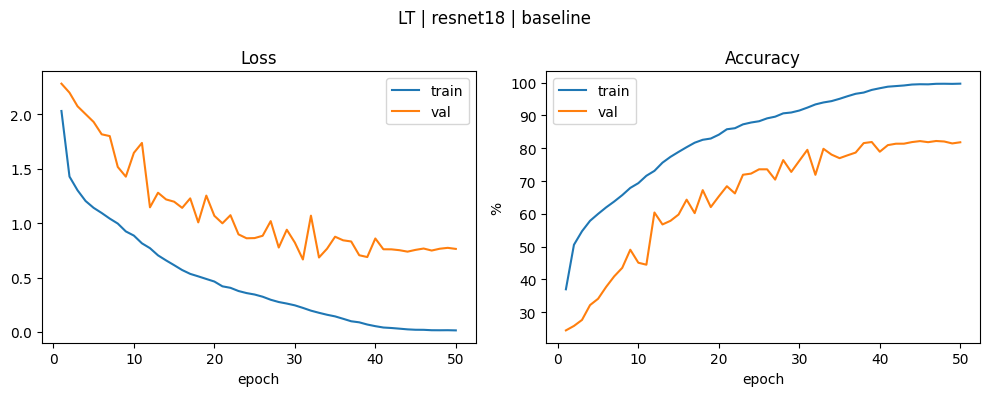


--- LT | densenet121 | baseline (no sampler, CE) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.594 acc=47.7%  val_loss=2.072 acc=28.7%
Ep 05 | train_loss=0.945 acc=67.1%  val_loss=1.772 acc=41.9%
Ep 10 | train_loss=0.642 acc=77.8%  val_loss=1.517 acc=53.8%
Ep 15 | train_loss=0.429 acc=85.6%  val_loss=1.386 acc=60.1%
Ep 20 | train_loss=0.318 acc=89.2%  val_loss=0.928 acc=71.1%
Ep 25 | train_loss=0.235 acc=91.8%  val_loss=0.848 acc=76.0%
Ep 30 | train_loss=0.142 acc=95.2%  val_loss=0.664 acc=81.1%
Ep 35 | train_loss=0.061 acc=97.9%  val_loss=0.761 acc=81.1%
Ep 40 | train_loss=0.015 acc=99.6%  val_loss=0.800 acc=82.0%
Ep 45 | train_loss=0.006 acc=99.9%  val_loss=0.704 acc=84.2%
Ep 50 | train_loss=0.005 acc=99.9%  val_loss=0.707 acc=84.3%

--- Classification report: LT | densenet121 | baseline ---
              precision    recall  f1-score   support

    airplane       0.74      0.97      0.84      1000
  automobile       0.81      0.99      0.89      1000
        bird       0.81      0.88      0.85      1000
         cat       0.70      0.83      0.76      100

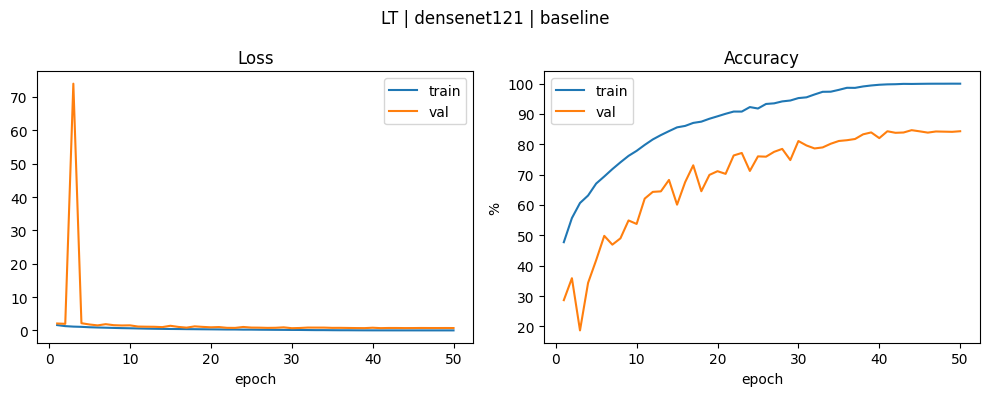


================  Scenario: SS  ================

--- SS | resnet18 | baseline (no sampler, CE) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.017 acc=34.2%  val_loss=2.549 acc=25.2%
Ep 05 | train_loss=1.141 acc=59.8%  val_loss=2.131 acc=32.6%
Ep 10 | train_loss=0.756 acc=74.1%  val_loss=1.530 acc=48.5%
Ep 15 | train_loss=0.493 acc=83.3%  val_loss=1.073 acc=66.0%
Ep 20 | train_loss=0.384 acc=87.1%  val_loss=1.039 acc=66.6%
Ep 25 | train_loss=0.294 acc=90.0%  val_loss=0.888 acc=73.8%
Ep 30 | train_loss=0.207 acc=93.0%  val_loss=0.858 acc=76.2%
Ep 35 | train_loss=0.122 acc=95.9%  val_loss=0.762 acc=79.6%
Ep 40 | train_loss=0.045 acc=98.5%  val_loss=0.655 acc=84.4%
Ep 45 | train_loss=0.014 acc=99.7%  val_loss=0.715 acc=84.0%
Ep 50 | train_loss=0.010 acc=99.8%  val_loss=0.736 acc=84.0%

--- Classification report: SS | resnet18 | baseline ---
              precision    recall  f1-score   support

    airplane       0.79      0.96      0.87      1000
  automobile       0.88      0.98      0.93      1000
        bird       0.81      0.91      0.86      1000
         cat       0.59      0.91      0.72      1000
 

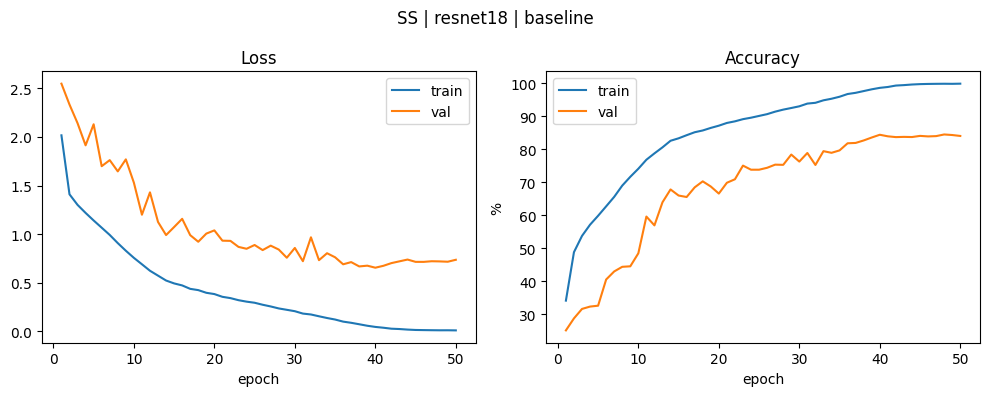


--- SS | densenet121 | baseline (no sampler, CE) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.488 acc=48.1%  val_loss=2.150 acc=30.9%
Ep 05 | train_loss=0.703 acc=76.3%  val_loss=1.252 acc=59.1%
Ep 10 | train_loss=0.403 acc=86.2%  val_loss=0.806 acc=72.8%
Ep 15 | train_loss=0.319 acc=89.2%  val_loss=0.936 acc=71.8%
Ep 20 | train_loss=0.256 acc=91.4%  val_loss=0.765 acc=76.9%
Ep 25 | train_loss=0.202 acc=93.1%  val_loss=0.749 acc=77.2%
Ep 30 | train_loss=0.139 acc=95.3%  val_loss=0.742 acc=79.8%
Ep 35 | train_loss=0.068 acc=97.8%  val_loss=0.762 acc=81.3%
Ep 40 | train_loss=0.019 acc=99.5%  val_loss=0.736 acc=84.8%
Ep 45 | train_loss=0.006 acc=99.9%  val_loss=0.637 acc=86.7%
Ep 50 | train_loss=0.003 acc=100.0%  val_loss=0.632 acc=87.0%

--- Classification report: SS | densenet121 | baseline ---
              precision    recall  f1-score   support

    airplane       0.84      0.96      0.90      1000
  automobile       0.89      0.99      0.93      1000
        bird       0.83      0.93      0.88      1000
         cat       0.67      0.92      0.77      10

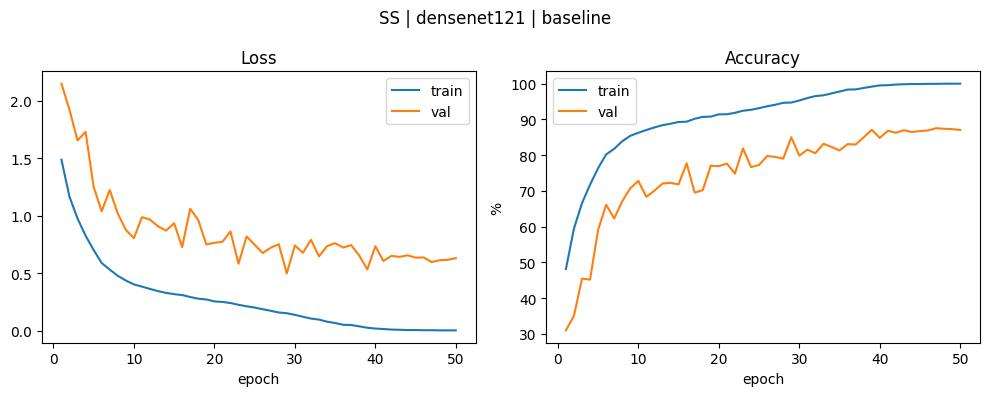


================  Scenario: AS  ================

--- AS | resnet18 | baseline (no sampler, CE) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=2.356 acc=50.4%  val_loss=8.226 acc=10.0%
Ep 05 | train_loss=1.362 acc=55.3%  val_loss=2.044 acc=22.1%
Ep 10 | train_loss=1.121 acc=61.7%  val_loss=1.740 acc=36.5%
Ep 15 | train_loss=0.943 acc=67.8%  val_loss=1.864 acc=36.5%
Ep 20 | train_loss=0.808 acc=72.8%  val_loss=1.616 acc=47.5%
Ep 25 | train_loss=0.659 acc=77.6%  val_loss=1.415 acc=53.8%
Ep 30 | train_loss=0.523 acc=81.7%  val_loss=1.211 acc=60.8%
Ep 35 | train_loss=0.395 acc=86.0%  val_loss=1.018 acc=67.5%
Ep 40 | train_loss=0.250 acc=91.4%  val_loss=0.972 acc=70.4%
Ep 45 | train_loss=0.142 acc=95.6%  val_loss=0.999 acc=72.0%
Ep 50 | train_loss=0.109 acc=96.9%  val_loss=1.023 acc=72.1%

--- Classification report: AS | resnet18 | baseline ---
              precision    recall  f1-score   support

    airplane       0.55      0.96      0.70      1000
  automobile       0.90      0.85      0.87      1000
        bird       0.69      0.56      0.62      1000
         cat       0.54      0.51      0.52      1000
 

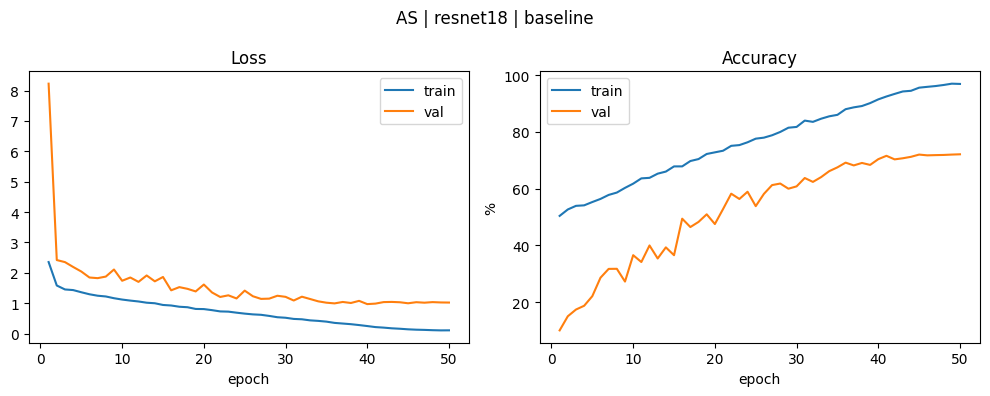


--- AS | densenet121 | baseline (no sampler, CE) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Ep 01 | train_loss=1.874 acc=50.5%  val_loss=2.825 acc=16.4%
Ep 05 | train_loss=1.175 acc=60.6%  val_loss=1.961 acc=31.0%
Ep 10 | train_loss=0.934 acc=68.2%  val_loss=1.540 acc=47.0%
Ep 15 | train_loss=0.722 acc=75.1%  val_loss=1.536 acc=50.4%
Ep 20 | train_loss=0.555 acc=81.1%  val_loss=1.421 acc=57.7%
Ep 25 | train_loss=0.428 acc=84.9%  val_loss=1.319 acc=60.2%
Ep 30 | train_loss=0.270 acc=90.6%  val_loss=1.074 acc=69.5%
Ep 35 | train_loss=0.137 acc=95.5%  val_loss=1.091 acc=71.7%
Ep 40 | train_loss=0.048 acc=98.7%  val_loss=1.193 acc=72.0%
Ep 45 | train_loss=0.018 acc=99.7%  val_loss=1.157 acc=74.1%
Ep 50 | train_loss=0.014 acc=99.8%  val_loss=1.136 acc=74.5%

--- Classification report: AS | densenet121 | baseline ---
              precision    recall  f1-score   support

    airplane       0.58      0.97      0.73      1000
  automobile       0.93      0.86      0.89      1000
        bird       0.74      0.58      0.65      1000
         cat       0.58      0.52      0.55      100

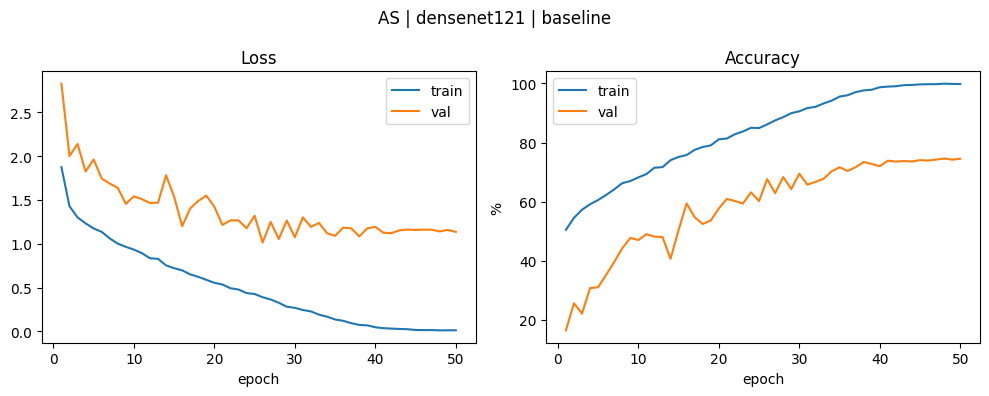

In [ ]:
summary_rows = []  # collect headline numbers for your slide/table

for scn_key, split in SPLITS.items():   # scn_key is "lt" / "ss" / "as"
    print(f"\n================  Scenario: {scn_key.upper()}  ================")
    indices = split["indices"]
    counts  = split["counts"]

    # Build the training loader for THIS scenario (BASELINE: no sampler)
    train_loader = make_train_loader_from_indices(train_data, indices, batch_size=CONFIG["batch_size"])

    for backbone in CONFIG["backbones"]:
        print(f"\n--- {scn_key.upper()} | {backbone} | baseline (no sampler, CE) ---")
        model = make_model(backbone, num_classes=10).to(device)
        criterion = nn.CrossEntropyLoss()  # baseline loss for all scenarios
        opt = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=0.9, weight_decay=5e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["epochs"])

        best_val = -1.0; best_state = None
        history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

        for ep in range(1, CONFIG["epochs"]+1):
            tl, ta = train_one_epoch(model, train_loader, criterion, opt)
            vl, va = evaluate(model, test_loader,  criterion)
            sched.step()

            history["train_loss"].append(tl); history["train_acc"].append(ta)
            history["val_loss"].append(vl);   history["val_acc"].append(va)

            # track best model by validation accuracy
            if va > best_val:
                best_val = va
                best_state = {k:v.cpu() for k,v in model.state_dict().items()}

            if ep == 1 or ep % 5 == 0:
              print(f"Ep {ep:02d} | train_loss={tl:.3f} acc={ta*100:.1f}%  val_loss={vl:.3f} acc={va*100:.1f}%")


        # restore best weights and compute macro metrics on the clean test set
        if best_state: model.load_state_dict(best_state)
        y_true, y_pred = get_preds(model, test_loader, device)
        cm   = confusion_matrix(y_true, y_pred, K=10)
        acc  = (y_true == y_pred).mean()
        mF1  = macro_f1(cm)
        bAcc = balanced_acc(cm)

        # === ADD: classification report (prints + saves) ===
        from sklearn.metrics import classification_report
        report = classification_report(
            y_true, y_pred,
            target_names=class_labels,   # e.g., ['airplane', ... 'truck']
            digits=2)
        print("\n--- Classification report:", f"{scn_key.upper()} | {backbone} | baseline ---")
        print(report)

        # save a copy
        os.makedirs("metrics", exist_ok=True)
        rep_path = os.path.join("metrics", f"{backbone}_{scn_key.upper()}_baseline_report.txt")
        with open(rep_path, "w") as f:
          f.write(report)
          print("Saved report to:", rep_path)




        print(f"Final test — Acc {acc*100:.2f}% | Macro-F1 {mF1*100:.2f}% | Balanced Acc {bAcc*100:.2f}%")

        # save checkpoint + metrics
        ckpt_path = os.path.join("ckpts", f"{backbone}_{scn_key.upper()}_baseline.pt")
        torch.save(model.state_dict(), ckpt_path)
        met = {
            "scenario": scn_key.upper(),
            "backbone": backbone,
            "epochs":   CONFIG["epochs"],
            "test_acc": float(acc),
            "macro_f1": float(mF1),
            "balanced_acc": float(bAcc),
            "history":  history,
        }
        met_path = os.path.join("metrics", f"{backbone}_{scn_key.upper()}_baseline.json")
        with open(met_path, "w") as f: json.dump(met, f, indent=2)

        # collect for summary table
        summary_rows.append([scn_key.upper(), backbone, round(mF1*100,2), round(bAcc*100,2), round(acc*100,2)])

        # (optional) quick curves for this run
        plot_curves(history, title=f"{scn_key.upper()} | {backbone} | baseline")


In [ ]:
import pandas as pd, os

cols = ["Scenario","Model","Macro-F1 (%)","Balanced Acc (%)","Overall Acc (%)"]
summary_df = pd.DataFrame(summary_rows, columns=cols).sort_values(["Scenario","Model"])
display(summary_df)

os.makedirs("metrics", exist_ok=True)
summary_csv = "metrics/summary_baselines.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)


,Scenario,Model,Macro-F1 (%),Balanced Acc (%),Overall Acc (%)
5,AS,densenet121,74.64,74.61,74.61
4,AS,resnet18,72.24,72.08,72.08
1,LT,densenet121,84.71,84.64,84.64
0,LT,resnet18,82.34,82.22,82.22
3,SS,densenet121,87.54,87.51,87.51
2,SS,resnet18,84.44,84.44,84.44


Saved: metrics/summary_baselines.csv
